# 7. SLI 연착륙 상품 공통 속성 분석

**목적:** 6번 노트북에서 선정된 146개 연착륙(Soft Landing) 상품이 **왜** 연착륙하는지, 6개 축에서 비연착륙(560개)과 비교하여 "연착륙 DNA"를 도출한다.

| 축 | 분석 내용 | 데이터 매칭률 |
|---|---|---|
| 1. 카테고리 | category_1/2 분포 차이 | 100% |
| 2. 가격대 | price_tier별 연착륙 비율 | 100% |
| 3. 검색트렌드 | 월별 검색량 시계열 비교 | 7.1% (한계) |
| 4. ABSA 감성 | 8개 aspect 감성 프로파일 | 100% |
| 5. 성분 패턴 | 성분 유형/알러지/Lift | 99.4% |
| 6. 기능성 | 미백/주름/자외선/여드름 | 29% (한계) |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact

# 색상 팔레트
SL_COLOR = '#2196F3'   # 연착륙 파랑
NSL_COLOR = '#FF9800'  # 비연착륙 주황
COLORS = [SL_COLOR, NSL_COLOR]

# 한글 폰트
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Noto Sans KR'
plt.rcParams['axes.unicode_minus'] = False


print('환경 설정 완료')

환경 설정 완료


In [2]:
import os

PROJECT_ROOT = '/Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi'
CSV_DIR = os.path.join(PROJECT_ROOT, '02_outputs/00_data/csv/final')
SLI_DIR = os.path.join(PROJECT_ROOT, '02_outputs/Sli')
ABSA_DIR = os.path.join(PROJECT_ROOT, '02_outputs/ABSA/snapshot_stage4b_rgx_20260227')
SEARCH_DIR = os.path.join(PROJECT_ROOT, '02_outputs/Search_Trend')
FIG_DIR = os.path.join(PROJECT_ROOT, '02_outputs/01_figures/SLI')
os.makedirs(FIG_DIR, exist_ok=True)

print(f'프로젝트 루트: {PROJECT_ROOT}')
print(f'차트 저장 경로: {FIG_DIR}')

프로젝트 루트: /Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi
차트 저장 경로: /Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi/02_outputs/01_figures/SLI


## 2. 데이터 로드 & 통합

In [3]:
# 기준 테이블: SLI 통합 결과
sli = pd.read_csv(os.path.join(SLI_DIR, 'sli_integrated_results.csv'))
print(f'SLI 통합 결과: {len(sli)}개 상품')
print(f'  연착륙: {sli.final_soft_landing.sum()}개 / 비연착륙: {(~sli.final_soft_landing.astype(bool)).sum()}개')

# 제품 통계
stats_df = pd.read_csv(os.path.join(CSV_DIR, 'products_stats.csv'))
print(f'제품 통계: {len(stats_df)}개')

# ABSA KPI
absa = pd.read_csv(os.path.join(ABSA_DIR, 'product_kpi.csv'))
print(f'ABSA KPI: {len(absa)}개')

# 성분 매핑
prod_ingr = pd.read_csv(os.path.join(CSV_DIR, 'products_ingredients.csv'))
ingr_dic = pd.read_csv(os.path.join(CSV_DIR, 'ingredients_dic.csv'))
print(f'성분 매핑: {len(prod_ingr)}행, 성분 사전: {len(ingr_dic)}종')

# 기능성
func = pd.read_csv(os.path.join(CSV_DIR, 'functional.csv'))
print(f'기능성: {len(func)}개')

# 검색트렌드
kw_map = pd.read_csv(os.path.join(SEARCH_DIR, 'keyword_mapping_20260225.csv'))
print(f'검색 키워드 매핑: {len(kw_map)}개')

SLI 통합 결과: 706개 상품
  연착륙: 146개 / 비연착륙: 560개
제품 통계: 948개
ABSA KPI: 937개
성분 매핑: 27975행, 성분 사전: 1741종
기능성: 256개
검색 키워드 매핑: 50개


In [4]:
# 마스터 테이블 생성 (sli 기준 left join)
master = sli[['product_code', 'name', 'brand_name', 'price', 'category_1', 'category_2',
              'final_soft_landing', 'confidence', 'ml_prob']].copy()
master['is_sl'] = master['final_soft_landing'].astype(bool)

# products_stats 조인
master = master.merge(
    stats_df[['product_code', 'review_count', 'engagement_score', 'review_density', 'likes', 'shares']],
    on='product_code', how='left'
)

# ABSA 조인 (aspect 컬럼만)
absa_cols = ['product_code', 'n_reviews', 'overall_pos_rate', 'overall_neu_rate', 'overall_neg_rate',
             'repurchase_mention_rate', 'ambiguous_rate', 'uncategorized_rate']
aspect_names = ['가격/가성비', '디자인', '배송/포장', '사용감/성능', '색상/발색', '용량/휴대', '재구매', '재질/냄새']
for a in aspect_names:
    absa_cols.append(f'mention_rate_{a}')
    absa_cols.append(f'neg_rate_{a}')
master = master.merge(absa[absa_cols], on='product_code', how='left')

# 기능성 조인
master = master.merge(func, on='product_code', how='left')

# 검색 키워드 매핑 조인
master = master.merge(
    kw_map[['product_code', 'search_keyword']],
    on='product_code', how='left'
)

# 가격 티어
def price_tier(p):
    if p <= 1000: return '1K'
    elif p <= 2000: return '2K'
    elif p <= 3000: return '3K'
    else: return '5K'
master['price_tier'] = master['price'].apply(price_tier)

# 기능성 여부 (is_whitening 등 존재하면 True)
func_cols = ['is_whitening', 'is_wrinkle_reduction', 'is_sunscreen', 'is_acne']
master['has_functional'] = master[func_cols].any(axis=1).fillna(False)

# 분리
sl = master[master['is_sl']]
nsl = master[~master['is_sl']]

print(f'마스터 테이블: {len(master)}행 × {len(master.columns)}열')
print(f'연착륙(SL): {len(sl)}개 / 비연착륙(Non-SL): {len(nsl)}개')
print(f'ABSA 매칭: {master.overall_pos_rate.notna().sum()}개')
print(f'기능성 매칭: {master.has_functional.notna().sum()}개 (기능성=True: {master.has_functional.sum()}개)')
print(f'검색 키워드 매칭: {master.search_keyword.notna().sum()}개')

마스터 테이블: 706행 × 47열
연착륙(SL): 146개 / 비연착륙(Non-SL): 560개
ABSA 매칭: 706개
기능성 매칭: 706개 (기능성=True: 191개)
검색 키워드 매칭: 50개


## 3. 개관 — 기초 통계 비교

In [5]:
# 기초 통계 비교: Mann-Whitney U 검정
compare_vars = {
    'price': '가격 (원)',
    'review_count': '리뷰 수',
    'engagement_score': '참여도 점수',
    'review_density': '리뷰 밀도'
}

stat_results = []
for var, label in compare_vars.items():
    sl_vals = sl[var].dropna()
    nsl_vals = nsl[var].dropna()
    u_stat, p_val = mannwhitneyu(sl_vals, nsl_vals, alternative='two-sided')
    stat_results.append({
        '변수': label,
        'SL 중앙값': sl_vals.median(),
        'Non-SL 중앙값': nsl_vals.median(),
        'SL 평균': sl_vals.mean(),
        'Non-SL 평균': nsl_vals.mean(),
        'U-statistic': u_stat,
        'p-value': p_val,
        '유의': '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    })

stat_df = pd.DataFrame(stat_results)
stat_df

,변수,SL 중앙값,Non-SL 중앙값,SL 평균,Non-SL 평균,U-statistic,p-value,유의
0,가격 (원),3000.0000,3000.00000,3595.890411,3900.000000,36526.5,2.729020e-02,*
1,리뷰 수,479.0000,173.00000,818.931507,341.105357,64694.0,1.990099e-27,***
2,참여도 점수,872.6250,375.65000,1101.807877,625.917857,57212.0,9.985745e-14,***
3,리뷰 밀도,0.6643,0.56845,1.242338,1.096275,43727.0,1.946499e-01,ns


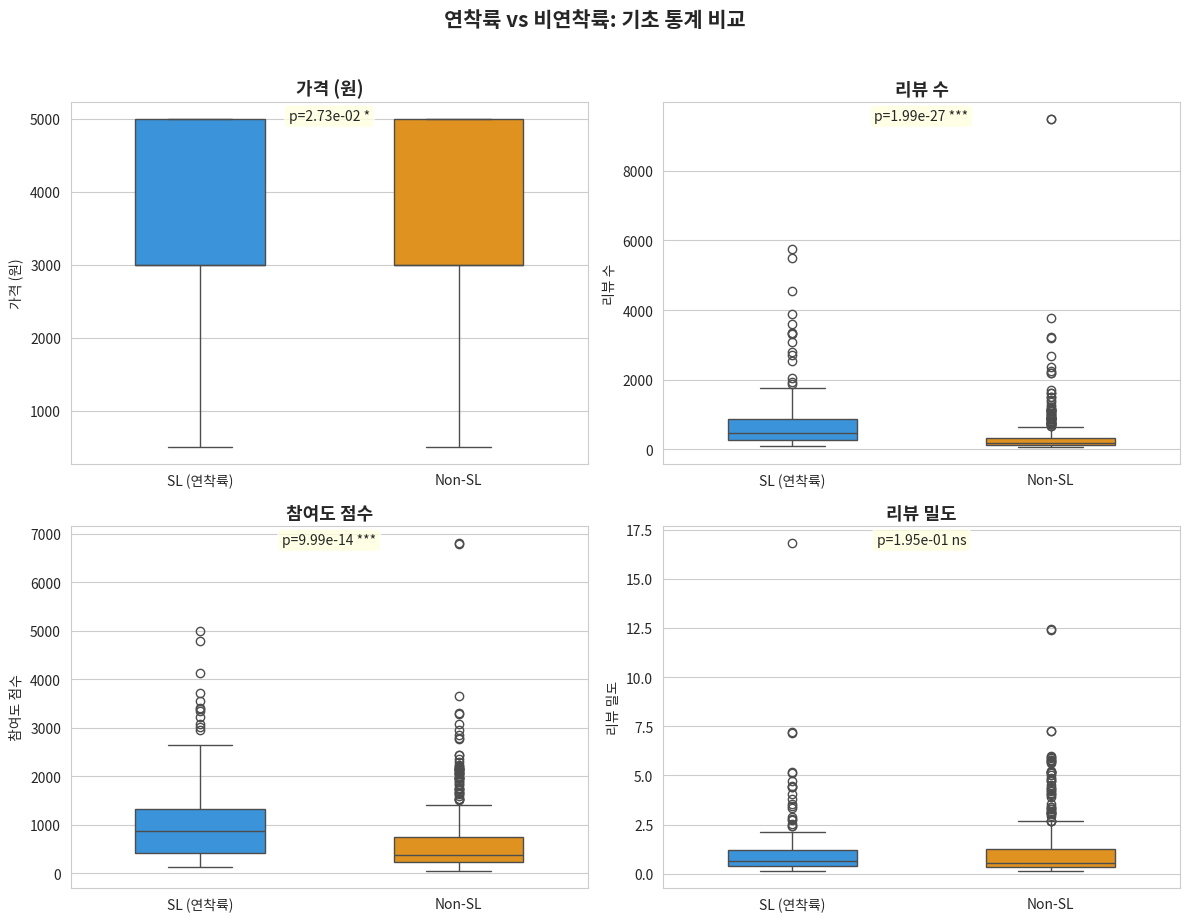

저장: 07_01_basic_stats_boxplot.png


In [6]:
# 2x2 박스플롯
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (var, label) in zip(axes.ravel(), compare_vars.items()):
    data_plot = master[[var, 'is_sl']].dropna()
    data_plot['그룹'] = data_plot['is_sl'].map({True: 'SL (연착륙)', False: 'Non-SL'})
    
    sns.boxplot(data=data_plot, x='그룹', y=var, palette=COLORS, ax=ax, width=0.5)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label)
    
    # p-value 표시
    row = stat_df[stat_df['변수'] == label].iloc[0]
    ax.text(0.5, 0.95, f"p={row['p-value']:.2e} {row['유의']}",
            transform=ax.transAxes, ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle('연착륙 vs 비연착륙: 기초 통계 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_01_basic_stats_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_01_basic_stats_boxplot.png')

## 4. 축1: 카테고리 분포

In [7]:
# category_1별 연착륙 비율
cat1_ct = master.groupby('category_1')['is_sl'].agg(['sum', 'count'])
cat1_ct.columns = ['sl_count', 'total']
cat1_ct['nsl_count'] = cat1_ct['total'] - cat1_ct['sl_count']
cat1_ct['sl_rate'] = cat1_ct['sl_count'] / cat1_ct['total']
cat1_ct = cat1_ct.sort_values('total', ascending=False)
cat1_ct

,sl_count,total,nsl_count,sl_rate
category_1,,,,
메이크업,46,353,307,0.130312
스킨케어,97,338,241,0.286982
맨케어,3,15,12,0.200000


In [8]:
# category_2별 연착륙 비율 + Over-Representation Ratio
overall_sl_rate = master['is_sl'].mean()

cat2_ct = master.groupby('category_2')['is_sl'].agg(['sum', 'count'])
cat2_ct.columns = ['sl_count', 'total']
cat2_ct['nsl_count'] = cat2_ct['total'] - cat2_ct['sl_count']
cat2_ct['sl_rate'] = cat2_ct['sl_count'] / cat2_ct['total']
cat2_ct['OR'] = cat2_ct['sl_rate'] / overall_sl_rate  # Over-Representation Ratio
cat2_ct = cat2_ct.sort_values('sl_rate', ascending=False)

# 카이제곱/Fisher 검정
cat2_for_test = master.groupby('category_2')['is_sl'].agg(['sum', 'count'])
cat2_for_test.columns = ['sl', 'total']
cat2_for_test['nsl'] = cat2_for_test['total'] - cat2_for_test['sl']

cat2_pvals = []
for cat in cat2_for_test.index:
    row = cat2_for_test.loc[cat]
    other_sl = cat2_for_test['sl'].sum() - row['sl']
    other_nsl = cat2_for_test['nsl'].sum() - row['nsl']
    table = [[row['sl'], row['nsl']], [other_sl, other_nsl]]
    
    if min(row['sl'], row['nsl'], other_sl, other_nsl) < 5:
        _, p = fisher_exact(table)
        method = 'Fisher'
    else:
        chi2, p, _, _ = chi2_contingency(table)
        method = 'Chi2'
    cat2_pvals.append({'category_2': cat, 'p_value': p, 'method': method})

cat2_pval_df = pd.DataFrame(cat2_pvals).set_index('category_2')
cat2_ct = cat2_ct.join(cat2_pval_df)
cat2_ct['sig'] = cat2_ct['p_value'].apply(lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

print(f'전체 연착륙 비율: {overall_sl_rate:.1%}')
cat2_ct

전체 연착륙 비율: 20.7%


,sl_count,total,nsl_count,sl_rate,OR,p_value,method,sig
category_2,,,,,,,,
남성향수,1,2,1,0.500000,2.417808,3.710646e-01,Fisher,ns
립케어,8,18,10,0.444444,2.149163,2.594582e-02,Chi2,*
팩/마스크,12,32,20,0.375000,1.813356,2.917874e-02,Chi2,*
클렌징/필링,23,70,47,0.328571,1.588845,1.259904e-02,Chi2,*
기초스킨케어,47,189,142,0.248677,1.202508,1.196546e-01,Chi2,ns
자외선차단제,7,29,22,0.241379,1.167218,8.138728e-01,Chi2,ns
아이메이크업,21,88,67,0.238636,1.153954,5.172988e-01,Chi2,ns
베이스메이크업,19,89,70,0.213483,1.032323,9.788038e-01,Chi2,ns
남성스킨케어,2,10,8,0.200000,0.967123,1.000000e+00,Fisher,ns


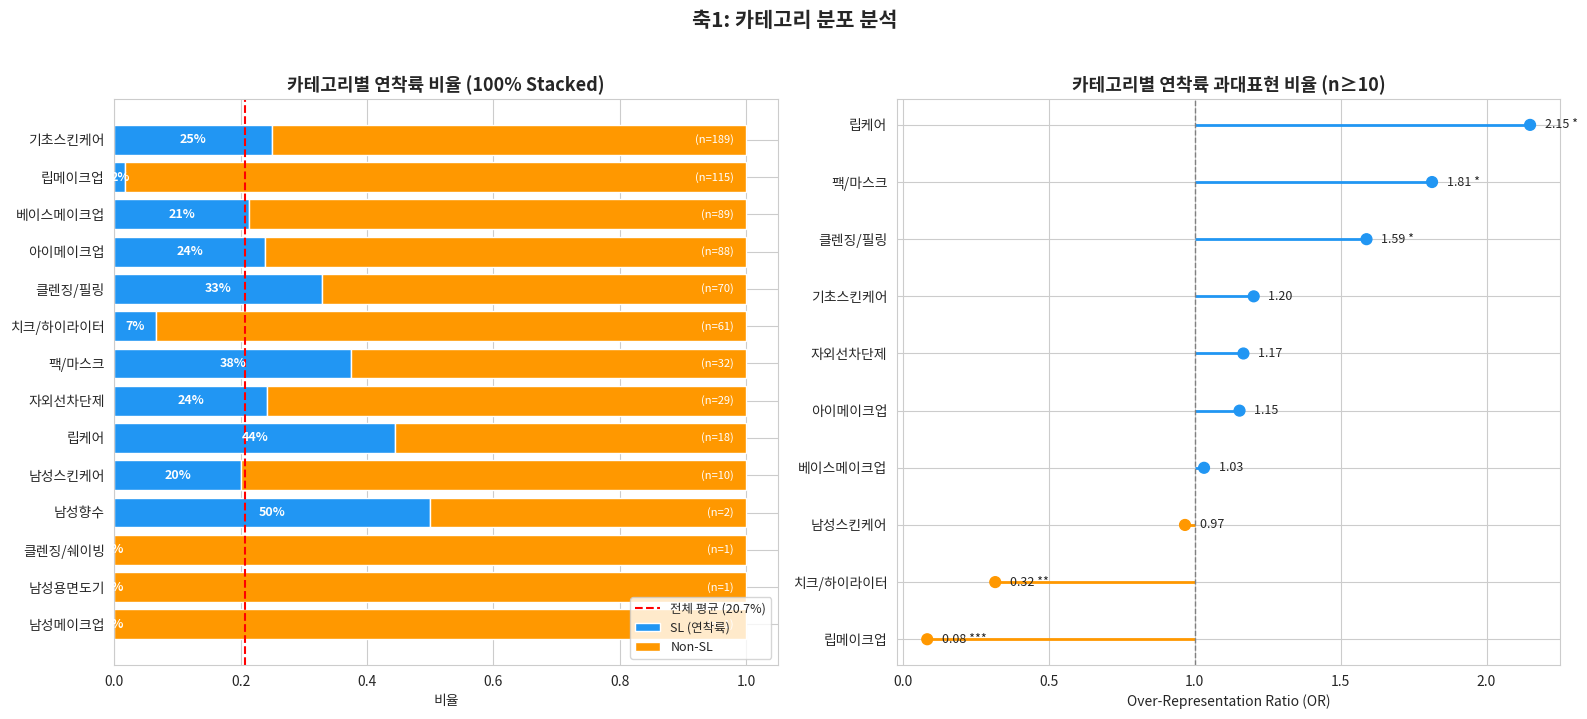

저장: 07_02_category_distribution.png


In [9]:
# 100% Stacked Bar: category_2별 SL/Non-SL 비율
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (좌) 100% Stacked Bar
cat2_plot = cat2_ct.sort_values('total', ascending=True).tail(15)  # 상위 15개
ax = axes[0]
ax.barh(cat2_plot.index, cat2_plot['sl_rate'], color=SL_COLOR, label='SL (연착륙)')
ax.barh(cat2_plot.index, 1 - cat2_plot['sl_rate'], left=cat2_plot['sl_rate'], color=NSL_COLOR, label='Non-SL')
ax.axvline(overall_sl_rate, color='red', linestyle='--', linewidth=1.5, label=f'전체 평균 ({overall_sl_rate:.1%})')
for i, (idx, row) in enumerate(cat2_plot.iterrows()):
    ax.text(row['sl_rate'] / 2, i, f"{row['sl_rate']:.0%}", ha='center', va='center', fontsize=9, fontweight='bold', color='white')
    ax.text(0.98, i, f"(n={int(row['total'])})", ha='right', va='center', fontsize=8, color='white')
ax.set_xlabel('비율')
ax.set_title('카테고리별 연착륙 비율 (100% Stacked)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

# (우) Lollipop: Over-Representation Ratio
cat2_or = cat2_ct[cat2_ct['total'] >= 10].sort_values('OR')  # 최소 10개 이상
ax = axes[1]
colors_or = [SL_COLOR if v >= 1 else NSL_COLOR for v in cat2_or['OR']]
ax.hlines(range(len(cat2_or)), 1, cat2_or['OR'], colors=colors_or, linewidth=2)
ax.scatter(cat2_or['OR'], range(len(cat2_or)), c=colors_or, s=60, zorder=3)
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(range(len(cat2_or)))
ax.set_yticklabels(cat2_or.index)
for i, (idx, row) in enumerate(cat2_or.iterrows()):
    sig = row['sig'] if row['sig'] != 'ns' else ''
    ax.text(row['OR'] + 0.05, i, f"{row['OR']:.2f} {sig}", va='center', fontsize=9)
ax.set_xlabel('Over-Representation Ratio (OR)')
ax.set_title('카테고리별 연착륙 과대표현 비율 (n≥10)', fontsize=13, fontweight='bold')

plt.suptitle('축1: 카테고리 분포 분석', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_02_category_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_02_category_distribution.png')

## 5. 축2: 가격대 분석

In [10]:
# price_tier별 연착륙 비율
tier_order = ['1K', '2K', '3K', '5K']
tier_ct = master.groupby('price_tier')['is_sl'].agg(['sum', 'count'])
tier_ct.columns = ['sl_count', 'total']
tier_ct['sl_rate'] = tier_ct['sl_count'] / tier_ct['total']
tier_ct = tier_ct.reindex(tier_order)

# Mann-Whitney U: 가격 비교
u_price, p_price = mannwhitneyu(sl['price'].dropna(), nsl['price'].dropna(), alternative='two-sided')

print(f'가격 Mann-Whitney U: U={u_price:.0f}, p={p_price:.4e}')
print(f'SL 가격 중앙값: {sl["price"].median():,.0f}원 / Non-SL: {nsl["price"].median():,.0f}원')
tier_ct

가격 Mann-Whitney U: U=36526, p=2.7290e-02
SL 가격 중앙값: 3,000원 / Non-SL: 3,000원


,sl_count,total,sl_rate
price_tier,,,
1K,15,27,0.555556
2K,13,34,0.382353
3K,52,304,0.171053
5K,66,341,0.193548


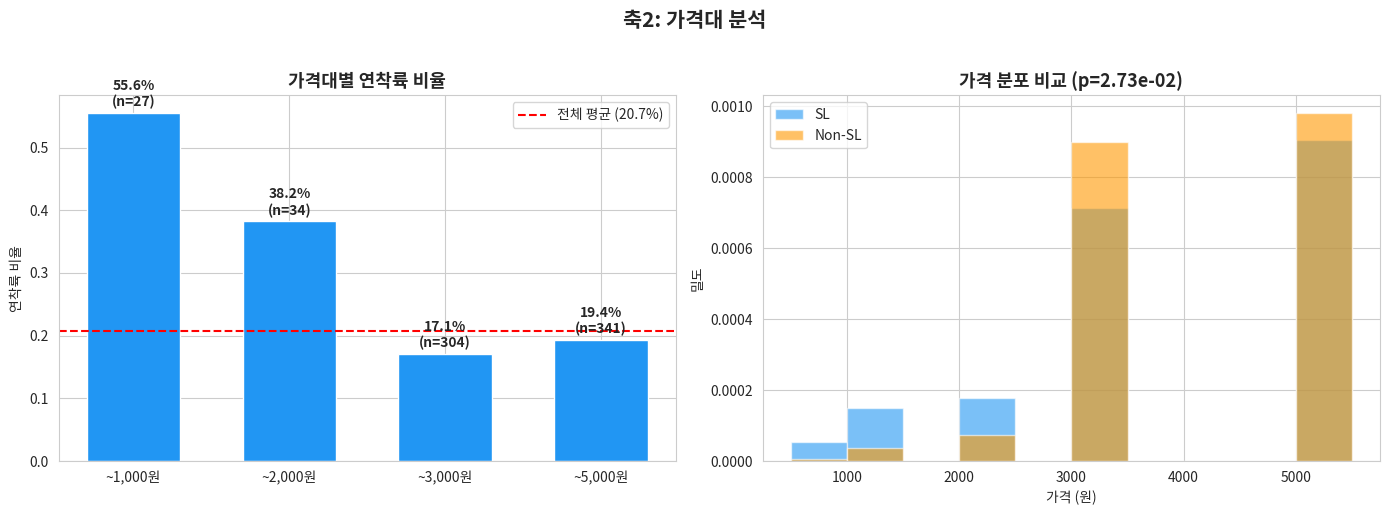

저장: 07_03_price_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 가격대별 연착륙 비율 Bar
ax = axes[0]
x = range(len(tier_order))
bars = ax.bar(x, tier_ct['sl_rate'], color=SL_COLOR, width=0.6, edgecolor='white')
ax.axhline(overall_sl_rate, color='red', linestyle='--', linewidth=1.5, label=f'전체 평균 ({overall_sl_rate:.1%})')
for i, (tier, row) in enumerate(tier_ct.iterrows()):
    ax.text(i, row['sl_rate'] + 0.01, f"{row['sl_rate']:.1%}\n(n={int(row['total'])})",
            ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['~1,000원', '~2,000원', '~3,000원', '~5,000원'])
ax.set_ylabel('연착륙 비율')
ax.set_title('가격대별 연착륙 비율', fontsize=13, fontweight='bold')
ax.legend()

# (우) 가격 히스토그램 오버랩
ax = axes[1]
bins = np.arange(500, 6000, 500)
ax.hist(sl['price'].dropna(), bins=bins, alpha=0.6, color=SL_COLOR, label='SL', density=True)
ax.hist(nsl['price'].dropna(), bins=bins, alpha=0.6, color=NSL_COLOR, label='Non-SL', density=True)
ax.set_xlabel('가격 (원)')
ax.set_ylabel('밀도')
ax.set_title(f'가격 분포 비교 (p={p_price:.2e})', fontsize=13, fontweight='bold')
ax.legend()

plt.suptitle('축2: 가격대 분석', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_03_price_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_03_price_analysis.png')

## 6. 축3: 검색 트렌드

> **한계점:** 검색 키워드 매칭률이 7.1% (706개 중 50개)로 낮아, 결과 해석에 주의가 필요합니다. 탐색적(exploratory) 분석으로만 참고하세요.

In [12]:
# 검색 트렌드 매칭 현황
sl_kw = master[master['is_sl'] & master['search_keyword'].notna()]
nsl_kw = master[~master['is_sl'] & master['search_keyword'].notna()]
print(f'검색 키워드 매칭: SL {len(sl_kw)}개 / Non-SL {len(nsl_kw)}개')
print(f'매칭률: SL {len(sl_kw)/len(sl):.1%} / Non-SL {len(nsl_kw)/len(nsl):.1%}')

검색 키워드 매칭: SL 20개 / Non-SL 30개
매칭률: SL 13.7% / Non-SL 5.4%


In [13]:
# 월별 검색량 시계열 로드 (브랜드 기준 anchor)
trend_anchor = pd.read_csv(os.path.join(SEARCH_DIR, 'search_trend_all-brand_anchor_20260225.csv'))
trend_anchor['period'] = pd.to_datetime(trend_anchor['period'])

# 키워드 매핑된 상품의 브랜드 추출
sl_brands = set(sl_kw['brand_name'].unique())
nsl_brands = set(nsl_kw['brand_name'].unique())

# 브랜드 기준으로 트렌드 필터
trend_sl = trend_anchor[trend_anchor['keyword_group'].isin(sl_brands)]
trend_nsl = trend_anchor[trend_anchor['keyword_group'].isin(nsl_brands - sl_brands)]  # 겹치지 않는 것만

print(f'트렌드 데이터: SL 브랜드 {trend_sl.keyword_group.nunique()}개 / Non-SL 브랜드 {trend_nsl.keyword_group.nunique()}개')

트렌드 데이터: SL 브랜드 10개 / Non-SL 브랜드 12개


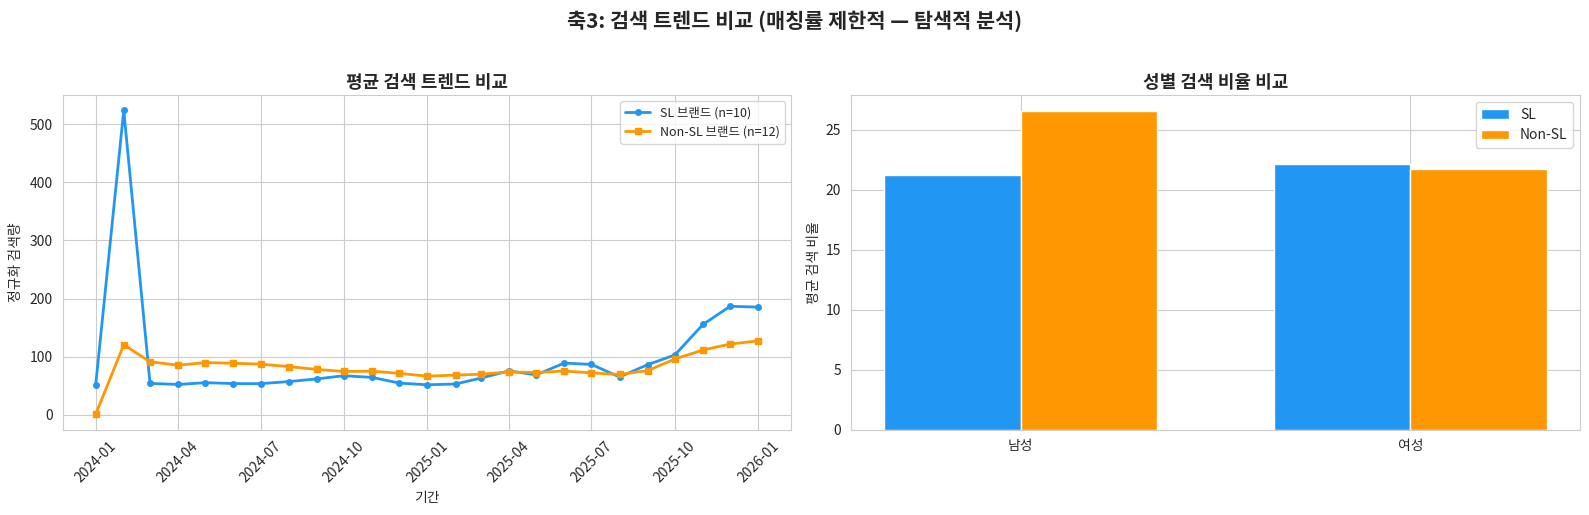

저장: 07_04_search_trend.png


In [14]:
# 월별 검색량 시계열 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (좌) 평균 검색 트렌드 시계열
ax = axes[0]
if len(trend_sl) > 0:
    ts_sl = trend_sl.groupby('period')['ratio_normalized'].mean()
    ax.plot(ts_sl.index, ts_sl.values, color=SL_COLOR, linewidth=2, label=f'SL 브랜드 (n={trend_sl.keyword_group.nunique()})', marker='o', markersize=4)
if len(trend_nsl) > 0:
    ts_nsl = trend_nsl.groupby('period')['ratio_normalized'].mean()
    ax.plot(ts_nsl.index, ts_nsl.values, color=NSL_COLOR, linewidth=2, label=f'Non-SL 브랜드 (n={trend_nsl.keyword_group.nunique()})', marker='s', markersize=4)
ax.set_xlabel('기간')
ax.set_ylabel('정규화 검색량')
ax.set_title('평균 검색 트렌드 비교', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

# (우) 성별/연령 세그먼트
ax = axes[1]
trend_seg = pd.read_csv(os.path.join(SEARCH_DIR, 'search_trend_all-brand_segment_20260225.csv'))
trend_seg['period'] = pd.to_datetime(trend_seg['period'])

# 성별 비교 (SL vs Non-SL)
seg_gender = trend_seg[trend_seg['segment_type'] == 'gender']
seg_sl_g = seg_gender[seg_gender['keyword_group'].isin(sl_brands)].groupby('segment_label')['ratio'].mean()
seg_nsl_g = seg_gender[seg_gender['keyword_group'].isin(nsl_brands - sl_brands)].groupby('segment_label')['ratio'].mean()

if len(seg_sl_g) > 0 and len(seg_nsl_g) > 0:
    x_pos = np.arange(len(seg_sl_g))
    w = 0.35
    ax.bar(x_pos - w/2, seg_sl_g.values, w, color=SL_COLOR, label='SL')
    ax.bar(x_pos + w/2, seg_nsl_g.reindex(seg_sl_g.index).values, w, color=NSL_COLOR, label='Non-SL')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(seg_sl_g.index)
    ax.set_ylabel('평균 검색 비율')
    ax.set_title('성별 검색 비율 비교', fontsize=13, fontweight='bold')
    ax.legend()

plt.suptitle('축3: 검색 트렌드 비교 (매칭률 제한적 — 탐색적 분석)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_04_search_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_04_search_trend.png')

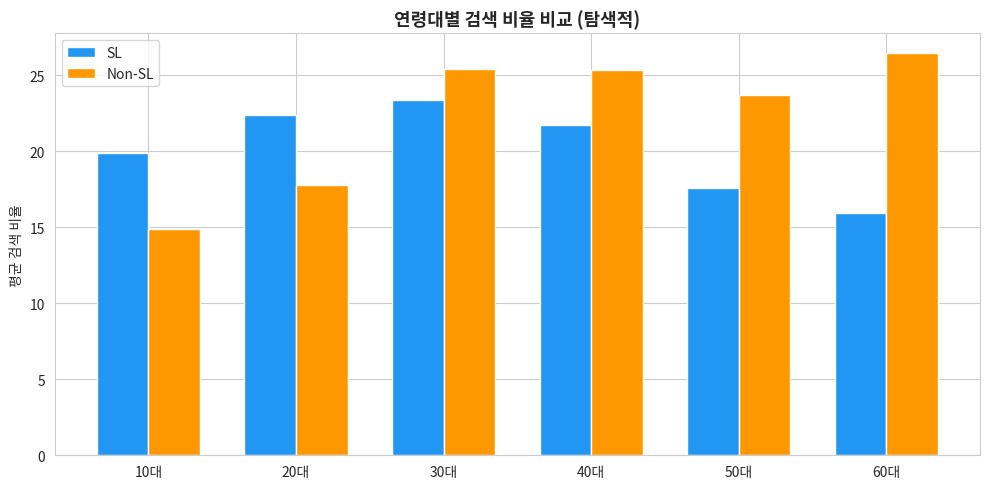

저장: 07_05_search_trend_age.png


In [15]:
# 연령대별 검색 비교
fig, ax = plt.subplots(figsize=(10, 5))

seg_age = trend_seg[trend_seg['segment_type'] == 'age']
seg_sl_a = seg_age[seg_age['keyword_group'].isin(sl_brands)].groupby('segment_label')['ratio'].mean()
seg_nsl_a = seg_age[seg_age['keyword_group'].isin(nsl_brands - sl_brands)].groupby('segment_label')['ratio'].mean()

if len(seg_sl_a) > 0 and len(seg_nsl_a) > 0:
    age_order = sorted(seg_sl_a.index, key=lambda x: int(x.replace('대', '')) if x.replace('대', '').isdigit() else 0)
    seg_sl_a = seg_sl_a.reindex(age_order)
    seg_nsl_a = seg_nsl_a.reindex(age_order)
    
    x_pos = np.arange(len(age_order))
    w = 0.35
    ax.bar(x_pos - w/2, seg_sl_a.values, w, color=SL_COLOR, label='SL')
    ax.bar(x_pos + w/2, seg_nsl_a.values, w, color=NSL_COLOR, label='Non-SL')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(age_order)
    ax.set_ylabel('평균 검색 비율')
    ax.set_title('연령대별 검색 비율 비교 (탐색적)', fontsize=13, fontweight='bold')
    ax.legend()

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_05_search_trend_age.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_05_search_trend_age.png')

## 7. 축4: ABSA 감성 프로파일

In [16]:
# 전체 감성 비교 (pos/neu/neg)
sentiment_cols = ['overall_pos_rate', 'overall_neu_rate', 'overall_neg_rate']
sentiment_labels = ['긍정', '중립', '부정']

sent_results = []
for col, label in zip(sentiment_cols, sentiment_labels):
    sl_v = sl[col].dropna()
    nsl_v = nsl[col].dropna()
    u, p = mannwhitneyu(sl_v, nsl_v, alternative='two-sided')
    sent_results.append({
        '감성': label,
        'SL 평균': sl_v.mean(),
        'Non-SL 평균': nsl_v.mean(),
        '차이': sl_v.mean() - nsl_v.mean(),
        'p-value': p,
        '유의': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    })

sent_df = pd.DataFrame(sent_results)
sent_df

,감성,SL 평균,Non-SL 평균,차이,p-value,유의
0,긍정,0.692292,0.647991,0.044301,4.752461e-13,***
1,중립,0.264263,0.288009,-0.023746,1.016308e-05,***
2,부정,0.043445,0.064000,-0.020555,6.789441e-09,***


In [17]:
# 8개 aspect mention_rate 비교 (Bonferroni 보정: α=0.05/8=0.00625)
ALPHA_BONF = 0.05 / 8

aspect_results = []
for a in aspect_names:
    col = f'mention_rate_{a}'
    sl_v = sl[col].dropna()
    nsl_v = nsl[col].dropna()
    u, p = mannwhitneyu(sl_v, nsl_v, alternative='two-sided')
    
    # Cohen's d
    pooled_std = np.sqrt((sl_v.std()**2 + nsl_v.std()**2) / 2)
    d = (sl_v.mean() - nsl_v.mean()) / pooled_std if pooled_std > 0 else 0
    
    aspect_results.append({
        'aspect': a,
        'SL_mean': sl_v.mean(),
        'NSL_mean': nsl_v.mean(),
        'diff': sl_v.mean() - nsl_v.mean(),
        'cohens_d': d,
        'p_value': p,
        'sig_bonf': '***' if p < 0.001 else ('**' if p < ALPHA_BONF else ('*' if p < 0.05 else 'ns'))
    })

aspect_df = pd.DataFrame(aspect_results)
print(f'Bonferroni 보정 α = {ALPHA_BONF:.5f}')
aspect_df

Bonferroni 보정 α = 0.00625


,aspect,SL_mean,NSL_mean,diff,cohens_d,p_value,sig_bonf
0,가격/가성비,0.091342,0.066277,0.025066,0.755117,1.369003e-14,***
1,디자인,0.018244,0.047119,-0.028875,-0.868656,3.487990e-14,***
2,배송/포장,0.048958,0.044526,0.004432,0.179179,8.865010e-04,***
3,사용감/성능,0.464607,0.461335,0.003272,0.042030,4.282964e-01,ns
4,색상/발색,0.118129,0.242280,-0.124152,-0.706153,2.794532e-10,***
5,용량/휴대,0.029128,0.029733,-0.000604,-0.018093,3.109844e-01,ns
6,재구매,0.098234,0.071192,0.027042,0.818265,2.315244e-16,***
7,재질/냄새,0.032653,0.030242,0.002411,0.060110,7.219951e-01,ns


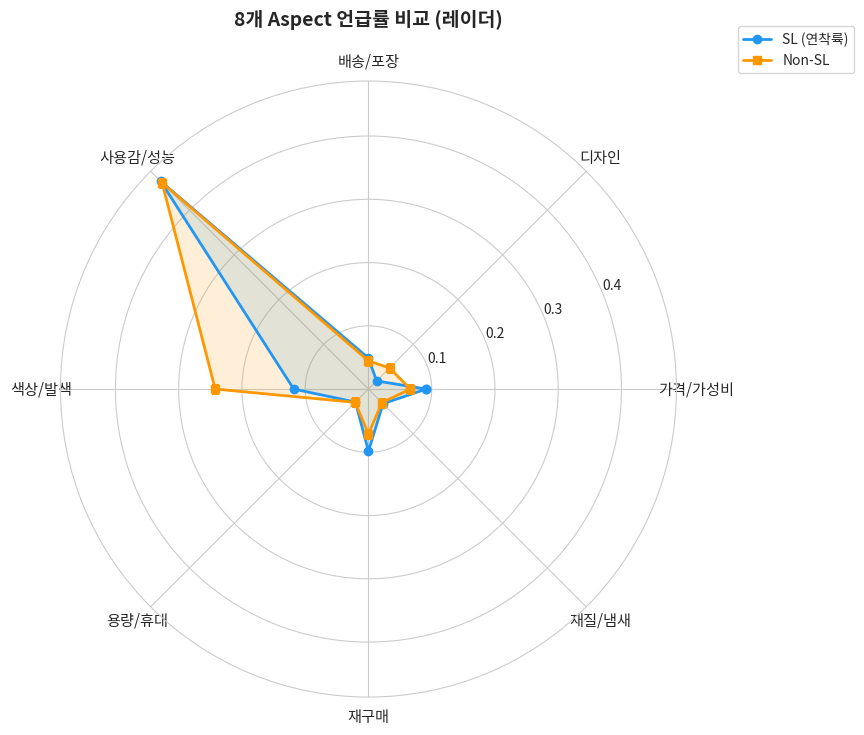

저장: 07_06_absa_radar.png


In [18]:
# 레이더 차트: aspect mention_rate
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

labels = aspect_df['aspect'].tolist()
sl_vals = aspect_df['SL_mean'].tolist()
nsl_vals = aspect_df['NSL_mean'].tolist()

# 레이더 각도
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
sl_vals_r = sl_vals + [sl_vals[0]]
nsl_vals_r = nsl_vals + [nsl_vals[0]]
angles_r = angles + [angles[0]]

ax.plot(angles_r, sl_vals_r, 'o-', color=SL_COLOR, linewidth=2, label='SL (연착륙)')
ax.fill(angles_r, sl_vals_r, alpha=0.15, color=SL_COLOR)
ax.plot(angles_r, nsl_vals_r, 's-', color=NSL_COLOR, linewidth=2, label='Non-SL')
ax.fill(angles_r, nsl_vals_r, alpha=0.15, color=NSL_COLOR)

ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('8개 Aspect 언급률 비교 (레이더)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

fig.savefig(os.path.join(FIG_DIR, '07_06_absa_radar.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_06_absa_radar.png')

In [19]:
# 8개 aspect neg_rate 비교
neg_results = []
for a in aspect_names:
    col = f'neg_rate_{a}'
    sl_v = sl[col].dropna()
    nsl_v = nsl[col].dropna()
    u, p = mannwhitneyu(sl_v, nsl_v, alternative='two-sided')
    neg_results.append({
        'aspect': a,
        'SL_neg': sl_v.mean(),
        'NSL_neg': nsl_v.mean(),
        'diff': sl_v.mean() - nsl_v.mean(),
        'p_value': p,
        'sig_bonf': '***' if p < 0.001 else ('**' if p < ALPHA_BONF else ('*' if p < 0.05 else 'ns'))
    })
neg_df = pd.DataFrame(neg_results)
neg_df

,aspect,SL_neg,NSL_neg,diff,p_value,sig_bonf
0,가격/가성비,0.002517,0.002965,-0.000448,0.007468,*
1,디자인,0.016259,0.018677,-0.002418,0.526995,ns
2,배송/포장,0.080176,0.086542,-0.006366,0.000812,***
3,사용감/성능,0.070312,0.097083,-0.026771,0.000002,***
4,색상/발색,0.092614,0.106384,-0.013769,0.280215,ns
5,용량/휴대,0.113072,0.111653,0.001419,0.003185,**
6,재구매,0.013434,0.027463,-0.014028,0.169663,ns
7,재질/냄새,0.153766,0.148068,0.005698,0.108696,ns


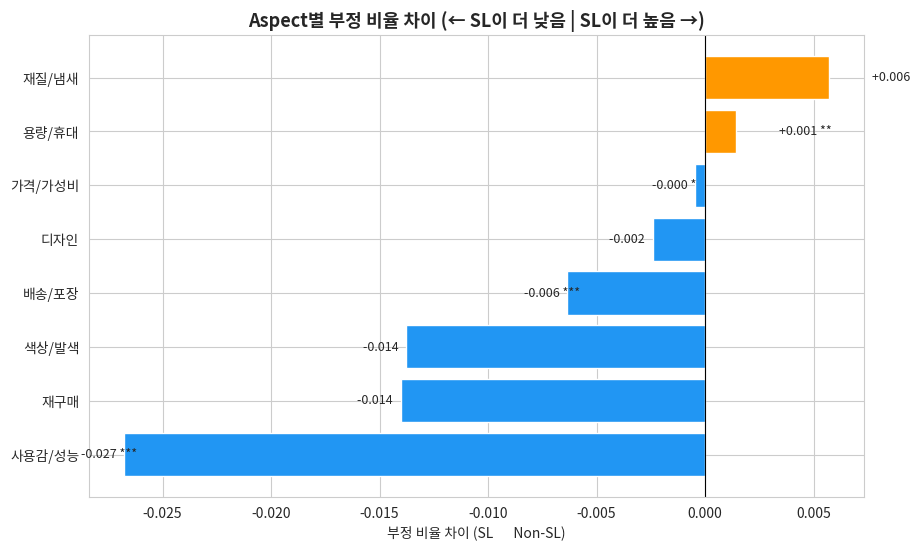

저장: 07_07_absa_neg_diverging.png


In [20]:
# Diverging Bar: aspect별 neg_rate 차이 (SL - Non-SL)
fig, ax = plt.subplots(figsize=(10, 6))

neg_sorted = neg_df.sort_values('diff')
colors_div = [SL_COLOR if d < 0 else NSL_COLOR for d in neg_sorted['diff']]
bars = ax.barh(neg_sorted['aspect'], neg_sorted['diff'], color=colors_div, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

for i, (_, row) in enumerate(neg_sorted.iterrows()):
    offset = -0.002 if row['diff'] < 0 else 0.002
    sig = row['sig_bonf'] if row['sig_bonf'] != 'ns' else ''
    ax.text(row['diff'] + offset, i, f"{row['diff']:+.3f} {sig}", va='center', fontsize=9)

ax.set_xlabel('부정 비율 차이 (SL − Non-SL)')
ax.set_title('Aspect별 부정 비율 차이 (← SL이 더 낮음 | SL이 더 높음 →)', fontsize=13, fontweight='bold')

fig.savefig(os.path.join(FIG_DIR, '07_07_absa_neg_diverging.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_07_absa_neg_diverging.png')

In [21]:
# 재구매 언급률 비교 + Cohen's d
sl_repurch = sl['repurchase_mention_rate'].dropna()
nsl_repurch = nsl['repurchase_mention_rate'].dropna()
u_rep, p_rep = mannwhitneyu(sl_repurch, nsl_repurch, alternative='two-sided')

pooled_std = np.sqrt((sl_repurch.std()**2 + nsl_repurch.std()**2) / 2)
cohens_d = (sl_repurch.mean() - nsl_repurch.mean()) / pooled_std if pooled_std > 0 else 0

print(f'재구매 언급률: SL={sl_repurch.mean():.3f} vs Non-SL={nsl_repurch.mean():.3f}')
print(f'Mann-Whitney U: p={p_rep:.4e}')
print(f"Cohen's d: {cohens_d:.3f} ({'작음' if abs(cohens_d) < 0.2 else ('중간' if abs(cohens_d) < 0.5 else '큼')})")

재구매 언급률: SL=0.098 vs Non-SL=0.071
Mann-Whitney U: p=2.3152e-16
Cohen's d: 0.818 (큼)


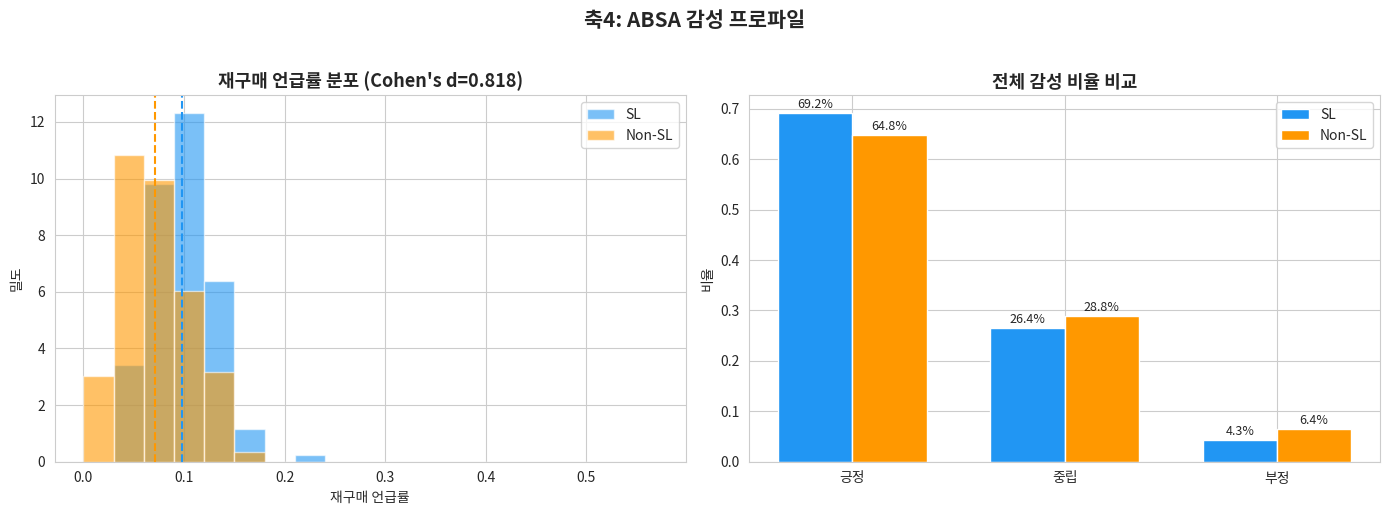

저장: 07_08_absa_repurchase_sentiment.png


In [22]:
# 재구매 언급률 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 히스토그램
ax = axes[0]
bins = np.arange(0, 0.6, 0.03)
ax.hist(sl_repurch, bins=bins, alpha=0.6, color=SL_COLOR, label='SL', density=True)
ax.hist(nsl_repurch, bins=bins, alpha=0.6, color=NSL_COLOR, label='Non-SL', density=True)
ax.axvline(sl_repurch.mean(), color=SL_COLOR, linestyle='--', linewidth=1.5)
ax.axvline(nsl_repurch.mean(), color=NSL_COLOR, linestyle='--', linewidth=1.5)
ax.set_xlabel('재구매 언급률')
ax.set_ylabel('밀도')
ax.set_title(f"재구매 언급률 분포 (Cohen's d={cohens_d:.3f})", fontsize=13, fontweight='bold')
ax.legend()

# (우) 전체 감성 비율 바
ax = axes[1]
x_pos = np.arange(3)
w = 0.35
sl_sent = [sent_df.iloc[0]['SL 평균'], sent_df.iloc[1]['SL 평균'], sent_df.iloc[2]['SL 평균']]
nsl_sent = [sent_df.iloc[0]['Non-SL 평균'], sent_df.iloc[1]['Non-SL 평균'], sent_df.iloc[2]['Non-SL 평균']]
ax.bar(x_pos - w/2, sl_sent, w, color=SL_COLOR, label='SL')
ax.bar(x_pos + w/2, nsl_sent, w, color=NSL_COLOR, label='Non-SL')
ax.set_xticks(x_pos)
ax.set_xticklabels(sentiment_labels)
for i in range(3):
    ax.text(i - w/2, sl_sent[i] + 0.01, f'{sl_sent[i]:.1%}', ha='center', fontsize=9)
    ax.text(i + w/2, nsl_sent[i] + 0.01, f'{nsl_sent[i]:.1%}', ha='center', fontsize=9)
ax.set_ylabel('비율')
ax.set_title('전체 감성 비율 비교', fontsize=13, fontweight='bold')
ax.legend()

plt.suptitle('축4: ABSA 감성 프로파일', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_08_absa_repurchase_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_08_absa_repurchase_sentiment.png')

## 8. 축5: 성분 패턴

In [23]:
# 성분 데이터 통합
ingr_full = prod_ingr.merge(ingr_dic, on='ingredient_id', how='left')

# SLI 상품과 매칭
sl_codes = set(sl['product_code'])
nsl_codes = set(nsl['product_code'])

ingr_sl = ingr_full[ingr_full['product_code'].isin(sl_codes)]
ingr_nsl = ingr_full[ingr_full['product_code'].isin(nsl_codes)]

print(f'성분 매칭: SL {ingr_sl.product_code.nunique()}개 / Non-SL {ingr_nsl.product_code.nunique()}개')
print(f'SL 총 성분 행: {len(ingr_sl)} / Non-SL: {len(ingr_nsl)}')

성분 매칭: SL 145개 / Non-SL 557개
SL 총 성분 행: 3859 / Non-SL: 18054


In [24]:
# ingredient_type별 분포 비교
sl_type_counts = ingr_sl.groupby('ingredient_type')['product_code'].nunique()
nsl_type_counts = ingr_nsl.groupby('ingredient_type')['product_code'].nunique()

n_sl_prod = ingr_sl.product_code.nunique()
n_nsl_prod = ingr_nsl.product_code.nunique()

sl_type_rate = (sl_type_counts / n_sl_prod).fillna(0)
nsl_type_rate = (nsl_type_counts / n_nsl_prod).fillna(0)

type_compare = pd.DataFrame({
    'SL_rate': sl_type_rate,
    'NSL_rate': nsl_type_rate
}).fillna(0)
type_compare['diff'] = type_compare['SL_rate'] - type_compare['NSL_rate']
type_compare = type_compare.sort_values('diff', ascending=False)

print('ingredient_type별 출현율 (상품 중 포함 비율):')
type_compare.head(15)

ingredient_type별 출현율 (상품 중 포함 비율):


,SL_rate,NSL_rate,diff
ingredient_type,,,
Chelator,0.503448,0.369838,0.133610
Water,0.613793,0.486535,0.127258
Amine,0.241379,0.172352,0.069027
Extract,0.641379,0.581688,0.059692
Other,0.213793,0.166966,0.046827
Paraben,0.034483,0.001795,0.032687
Alcohol,0.544828,0.533214,0.011614
Phenol,0.303448,0.292639,0.010809
Glycoside,0.103448,0.095153,0.008296


In [25]:
# 성분 Lift 분석: (SL 출현비율) / (Non-SL 출현비율)
sl_ingr_rate = ingr_sl.groupby('ingredient_name')['product_code'].nunique() / n_sl_prod
nsl_ingr_rate = ingr_nsl.groupby('ingredient_name')['product_code'].nunique() / n_nsl_prod

# 최소 출현 기준: SL 5개 이상
sl_ingr_count = ingr_sl.groupby('ingredient_name')['product_code'].nunique()
valid_ingr = sl_ingr_count[sl_ingr_count >= 5].index

lift_df = pd.DataFrame({
    'SL_rate': sl_ingr_rate.reindex(valid_ingr).fillna(0),
    'NSL_rate': nsl_ingr_rate.reindex(valid_ingr).fillna(0),
    'SL_count': sl_ingr_count.reindex(valid_ingr).fillna(0)
})
lift_df['lift'] = lift_df['SL_rate'] / lift_df['NSL_rate'].replace(0, 0.001)
lift_df = lift_df.sort_values('lift', ascending=False)

print('성분 Lift Top 20 (SL에서 과대표현):')
lift_df.head(20)

성분 Lift Top 20 (SL에서 과대표현):


,SL_rate,NSL_rate,SL_count,lift
ingredient_name,,,,
당호박추출물,0.034483,0.000000,5,34.482759
삼백초뿌리추출물,0.034483,0.000000,5,34.482759
부들레야추출물,0.034483,0.000000,5,34.482759
유채추출물,0.034483,0.000000,5,34.482759
익모초추출물,0.034483,0.000000,5,34.482759
자주개자리추출물,0.034483,0.000000,5,34.482759
양배추추출물,0.034483,0.000000,5,34.482759
삼백초잎추출물,0.034483,0.000000,5,34.482759
미리스틸미리스테이트,0.034483,0.001795,5,19.206897


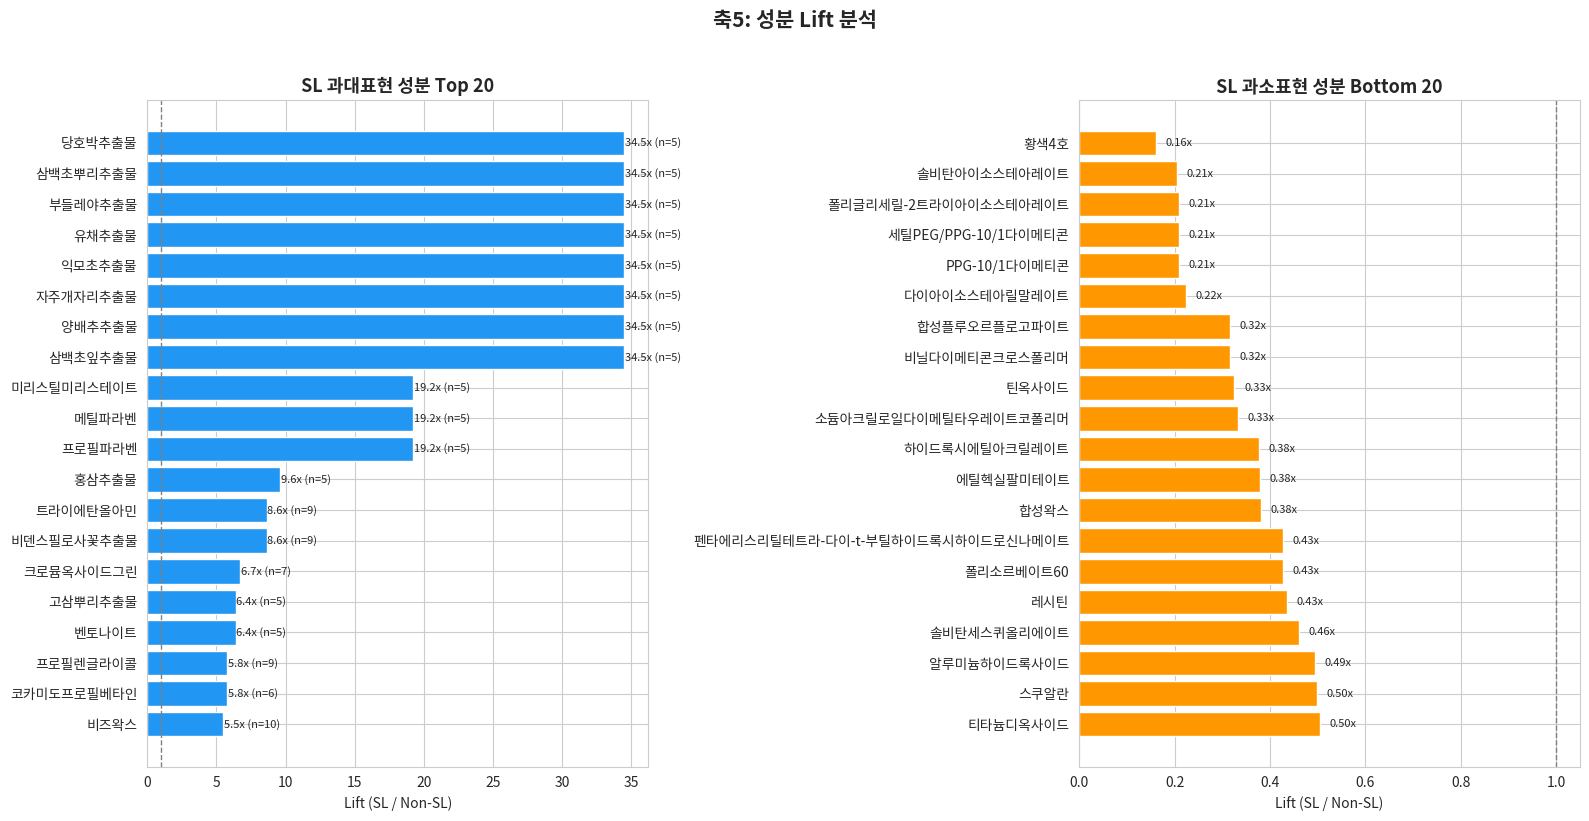

저장: 07_09_ingredient_lift.png


In [26]:
# 성분 Lift Top/Bottom 차트
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# (좌) Top 20 SL 과대표현 성분
ax = axes[0]
top20 = lift_df.head(20).sort_values('lift')
ax.barh(top20.index, top20['lift'], color=SL_COLOR, edgecolor='white')
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1)
for i, (idx, row) in enumerate(top20.iterrows()):
    ax.text(row['lift'] + 0.05, i, f"{row['lift']:.1f}x (n={int(row['SL_count'])})", va='center', fontsize=8)
ax.set_xlabel('Lift (SL / Non-SL)')
ax.set_title('SL 과대표현 성분 Top 20', fontsize=13, fontweight='bold')

# (우) Bottom 20 SL 과소표현 성분
ax = axes[1]
bottom20 = lift_df.tail(20).sort_values('lift', ascending=False)
ax.barh(bottom20.index, bottom20['lift'], color=NSL_COLOR, edgecolor='white')
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1)
for i, (idx, row) in enumerate(bottom20.iterrows()):
    ax.text(row['lift'] + 0.02, i, f"{row['lift']:.2f}x", va='center', fontsize=8)
ax.set_xlabel('Lift (SL / Non-SL)')
ax.set_title('SL 과소표현 성분 Bottom 20', fontsize=13, fontweight='bold')

plt.suptitle('축5: 성분 Lift 분석', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_09_ingredient_lift.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_09_ingredient_lift.png')

In [27]:
# 알러지 유발 성분 비율 비교 (Fisher)
sl_allergic = ingr_sl.groupby('product_code')['is_allergic'].any()
nsl_allergic = ingr_nsl.groupby('product_code')['is_allergic'].any()

sl_allergy_rate = sl_allergic.mean()
nsl_allergy_rate = nsl_allergic.mean()

# Fisher exact test
table_allergy = [
    [sl_allergic.sum(), (~sl_allergic).sum()],
    [nsl_allergic.sum(), (~nsl_allergic).sum()]
]
_, p_allergy = fisher_exact(table_allergy)

print(f'알러지 유발 성분 포함 비율:')
print(f'  SL: {sl_allergy_rate:.1%} ({sl_allergic.sum()}/{len(sl_allergic)})')
print(f'  Non-SL: {nsl_allergy_rate:.1%} ({nsl_allergic.sum()}/{len(nsl_allergic)})')
print(f'  Fisher p-value: {p_allergy:.4e}')

알러지 유발 성분 포함 비율:
  SL: 27.6% (40/145)
  Non-SL: 31.1% (173/557)
  Fisher p-value: 4.7795e-01


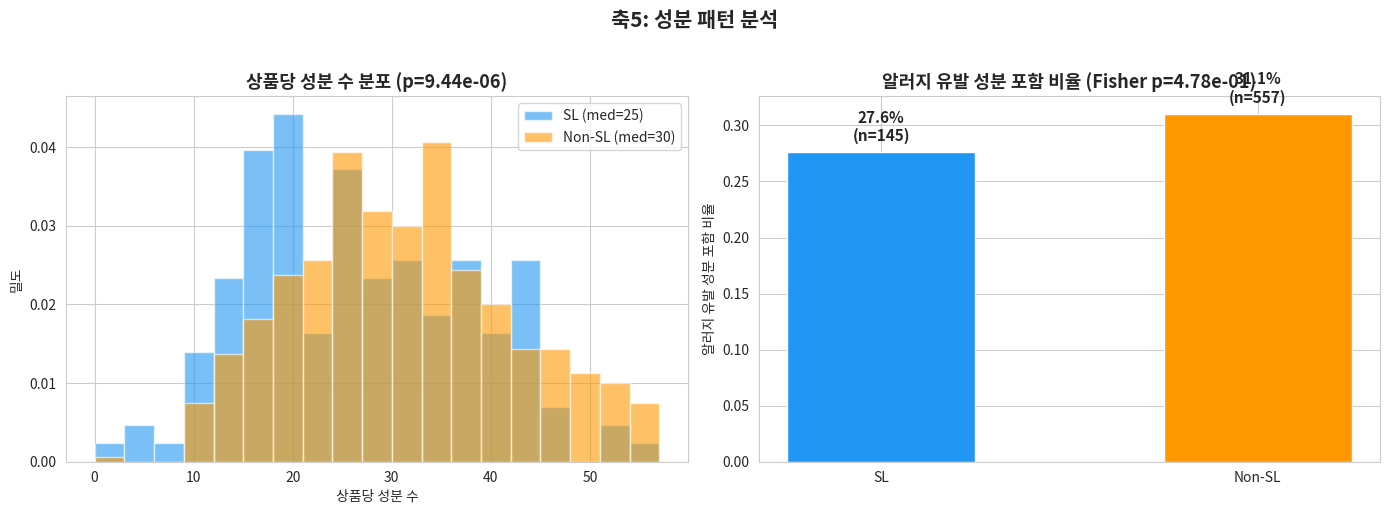

저장: 07_10_ingredient_allergy_count.png


In [28]:
# 상품당 성분 수 비교
sl_ingr_count_per = ingr_sl.groupby('product_code').size()
nsl_ingr_count_per = ingr_nsl.groupby('product_code').size()
u_ingr, p_ingr = mannwhitneyu(sl_ingr_count_per, nsl_ingr_count_per, alternative='two-sided')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 상품당 성분 수 분포
ax = axes[0]
bins = np.arange(0, 60, 3)
ax.hist(sl_ingr_count_per, bins=bins, alpha=0.6, color=SL_COLOR, label=f'SL (med={sl_ingr_count_per.median():.0f})', density=True)
ax.hist(nsl_ingr_count_per, bins=bins, alpha=0.6, color=NSL_COLOR, label=f'Non-SL (med={nsl_ingr_count_per.median():.0f})', density=True)
ax.set_xlabel('상품당 성분 수')
ax.set_ylabel('밀도')
ax.set_title(f'상품당 성분 수 분포 (p={p_ingr:.2e})', fontsize=13, fontweight='bold')
ax.legend()

# (우) 알러지 비율 비교 바
ax = axes[1]
ax.bar(['SL', 'Non-SL'], [sl_allergy_rate, nsl_allergy_rate], color=COLORS, width=0.5, edgecolor='white')
ax.set_ylabel('알러지 유발 성분 포함 비율')
ax.set_title(f'알러지 유발 성분 포함 비율 (Fisher p={p_allergy:.2e})', fontsize=13, fontweight='bold')
for i, (rate, n) in enumerate([(sl_allergy_rate, len(sl_allergic)), (nsl_allergy_rate, len(nsl_allergic))]):
    ax.text(i, rate + 0.01, f'{rate:.1%}\n(n={n})', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('축5: 성분 패턴 분석', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_10_ingredient_allergy_count.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_10_ingredient_allergy_count.png')

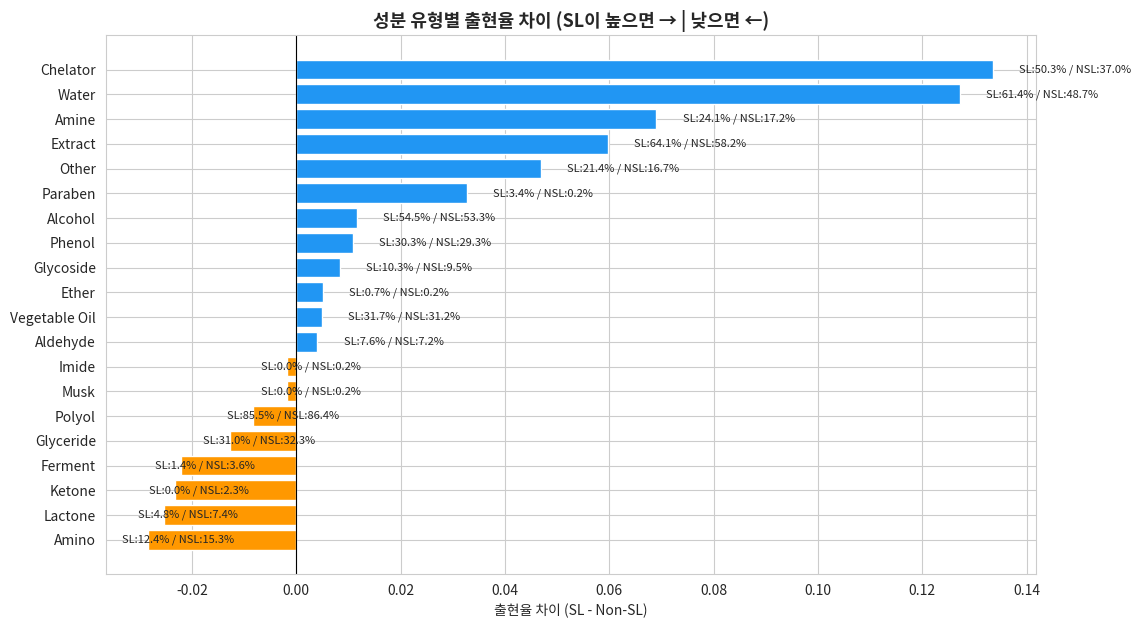

저장: 07_11_ingredient_type_diverging.png


In [29]:
# ingredient_type 분포 Diverging 차트
fig, ax = plt.subplots(figsize=(12, 7))

type_top = type_compare[type_compare.index.notna()].head(20).sort_values('diff')
colors_type = [SL_COLOR if d > 0 else NSL_COLOR for d in type_top['diff']]
ax.barh(type_top.index, type_top['diff'], color=colors_type, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for i, (idx, row) in enumerate(type_top.iterrows()):
    offset = 0.005 if row['diff'] > 0 else -0.005
    ax.text(row['diff'] + offset, i, f"SL:{row['SL_rate']:.1%} / NSL:{row['NSL_rate']:.1%}", va='center', fontsize=8)
ax.set_xlabel('출현율 차이 (SL - Non-SL)')
ax.set_title('성분 유형별 출현율 차이 (SL이 높으면 → | 낮으면 ←)', fontsize=13, fontweight='bold')

fig.savefig(os.path.join(FIG_DIR, '07_11_ingredient_type_diverging.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_11_ingredient_type_diverging.png')

## 9. 축6: 기능성 화장품

> **한계점:** 기능성 매칭률 29% (전체 706개 중 205개). 기능성 등록은 식약처 인증 제품만 해당하므로, 비등록 제품이 기능성이 없다는 뜻은 아닙니다.

In [30]:
# 기능성 등록 비율 비교
sl_func = sl['has_functional'].sum()
nsl_func = nsl['has_functional'].sum()
sl_func_rate = sl_func / len(sl)
nsl_func_rate = nsl_func / len(nsl)

table_func = [
    [sl_func, len(sl) - sl_func],
    [nsl_func, len(nsl) - nsl_func]
]
_, p_func = fisher_exact(table_func)

print(f'기능성 등록 비율: SL {sl_func_rate:.1%} ({sl_func}/{len(sl)}) / Non-SL {nsl_func_rate:.1%} ({nsl_func}/{len(nsl)})')
print(f'Fisher p-value: {p_func:.4e}')

기능성 등록 비율: SL 28.1% (41/146) / Non-SL 26.8% (150/560)
Fisher p-value: 7.5444e-01


In [31]:
# 4개 기능성 유형별 비교 (Bonferroni α=0.05/4=0.0125)
ALPHA_FUNC = 0.05 / 4
func_types = {
    'is_whitening': '미백',
    'is_wrinkle_reduction': '주름개선',
    'is_sunscreen': '자외선차단',
    'is_acne': '여드름'
}

func_results = []
for col, label in func_types.items():
    sl_v = sl[col].fillna(False).astype(bool).sum()
    nsl_v = nsl[col].fillna(False).astype(bool).sum()
    table = [[sl_v, len(sl) - sl_v], [nsl_v, len(nsl) - nsl_v]]
    _, p = fisher_exact(table)
    func_results.append({
        '유형': label,
        'SL_count': sl_v, 'SL_rate': sl_v / len(sl),
        'NSL_count': nsl_v, 'NSL_rate': nsl_v / len(nsl),
        'p_value': p,
        'sig': '***' if p < 0.001 else ('**' if p < ALPHA_FUNC else ('*' if p < 0.05 else 'ns'))
    })

func_df = pd.DataFrame(func_results)
print(f'Bonferroni 보정 α = {ALPHA_FUNC}')
func_df

Bonferroni 보정 α = 0.0125


,유형,SL_count,SL_rate,NSL_count,NSL_rate,p_value,sig
0,미백,18,0.123288,85,0.151786,0.431464,ns
1,주름개선,16,0.109589,75,0.133929,0.490009,ns
2,자외선차단,18,0.123288,50,0.089286,0.210857,ns
3,여드름,4,0.027397,4,0.007143,0.061650,ns


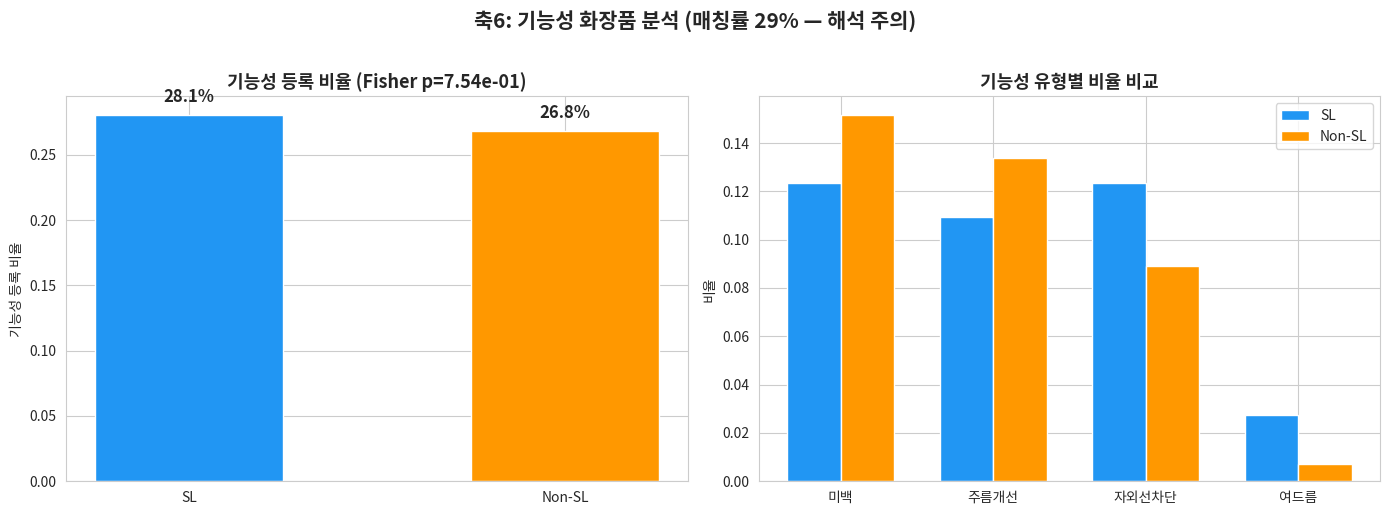

저장: 07_12_functional.png


In [32]:
# 기능성 비교 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 기능성 등록 비율
ax = axes[0]
ax.bar(['SL', 'Non-SL'], [sl_func_rate, nsl_func_rate], color=COLORS, width=0.5)
ax.set_ylabel('기능성 등록 비율')
ax.set_title(f'기능성 등록 비율 (Fisher p={p_func:.2e})', fontsize=13, fontweight='bold')
for i, (rate, n) in enumerate([(sl_func_rate, len(sl)), (nsl_func_rate, len(nsl))]):
    ax.text(i, rate + 0.01, f'{rate:.1%}', ha='center', fontsize=12, fontweight='bold')

# (우) 4개 유형별
ax = axes[1]
x_pos = np.arange(len(func_df))
w = 0.35
ax.bar(x_pos - w/2, func_df['SL_rate'], w, color=SL_COLOR, label='SL')
ax.bar(x_pos + w/2, func_df['NSL_rate'], w, color=NSL_COLOR, label='Non-SL')
ax.set_xticks(x_pos)
ax.set_xticklabels(func_df['유형'])
for i, row in func_df.iterrows():
    sig = row['sig'] if row['sig'] != 'ns' else ''
    y_max = max(row['SL_rate'], row['NSL_rate'])
    ax.text(i, y_max + 0.01, sig, ha='center', fontsize=10, color='red')
ax.set_ylabel('비율')
ax.set_title('기능성 유형별 비율 비교', fontsize=13, fontweight='bold')
ax.legend()

plt.suptitle('축6: 기능성 화장품 분석 (매칭률 29% — 해석 주의)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_12_functional.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_12_functional.png')

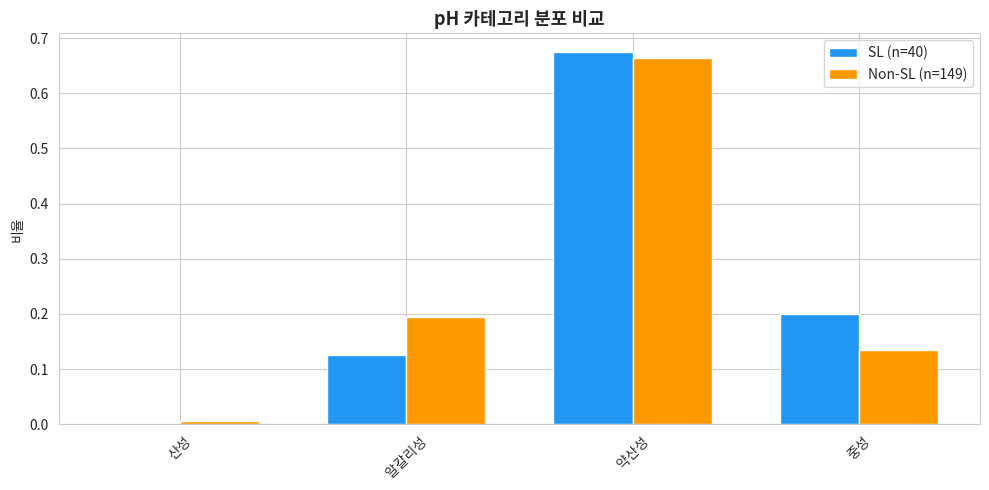

저장: 07_13_ph_distribution.png


In [33]:
# pH 카테고리 분포 비교
sl_ph = sl['ph_category'].dropna()
nsl_ph = nsl['ph_category'].dropna()

if len(sl_ph) > 5 and len(nsl_ph) > 5:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ph_cats = sorted(set(sl_ph) | set(nsl_ph))
    sl_ph_dist = sl_ph.value_counts(normalize=True).reindex(ph_cats, fill_value=0)
    nsl_ph_dist = nsl_ph.value_counts(normalize=True).reindex(ph_cats, fill_value=0)
    
    x_pos = np.arange(len(ph_cats))
    w = 0.35
    ax.bar(x_pos - w/2, sl_ph_dist, w, color=SL_COLOR, label=f'SL (n={len(sl_ph)})')
    ax.bar(x_pos + w/2, nsl_ph_dist, w, color=NSL_COLOR, label=f'Non-SL (n={len(nsl_ph)})')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ph_cats, rotation=45)
    ax.set_ylabel('비율')
    ax.set_title('pH 카테고리 분포 비교', fontsize=13, fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, '07_13_ph_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: 07_13_ph_distribution.png')
else:
    print(f'pH 데이터 부족: SL {len(sl_ph)}개 / Non-SL {len(nsl_ph)}개')

## 10. 종합 결론: 연착륙 DNA

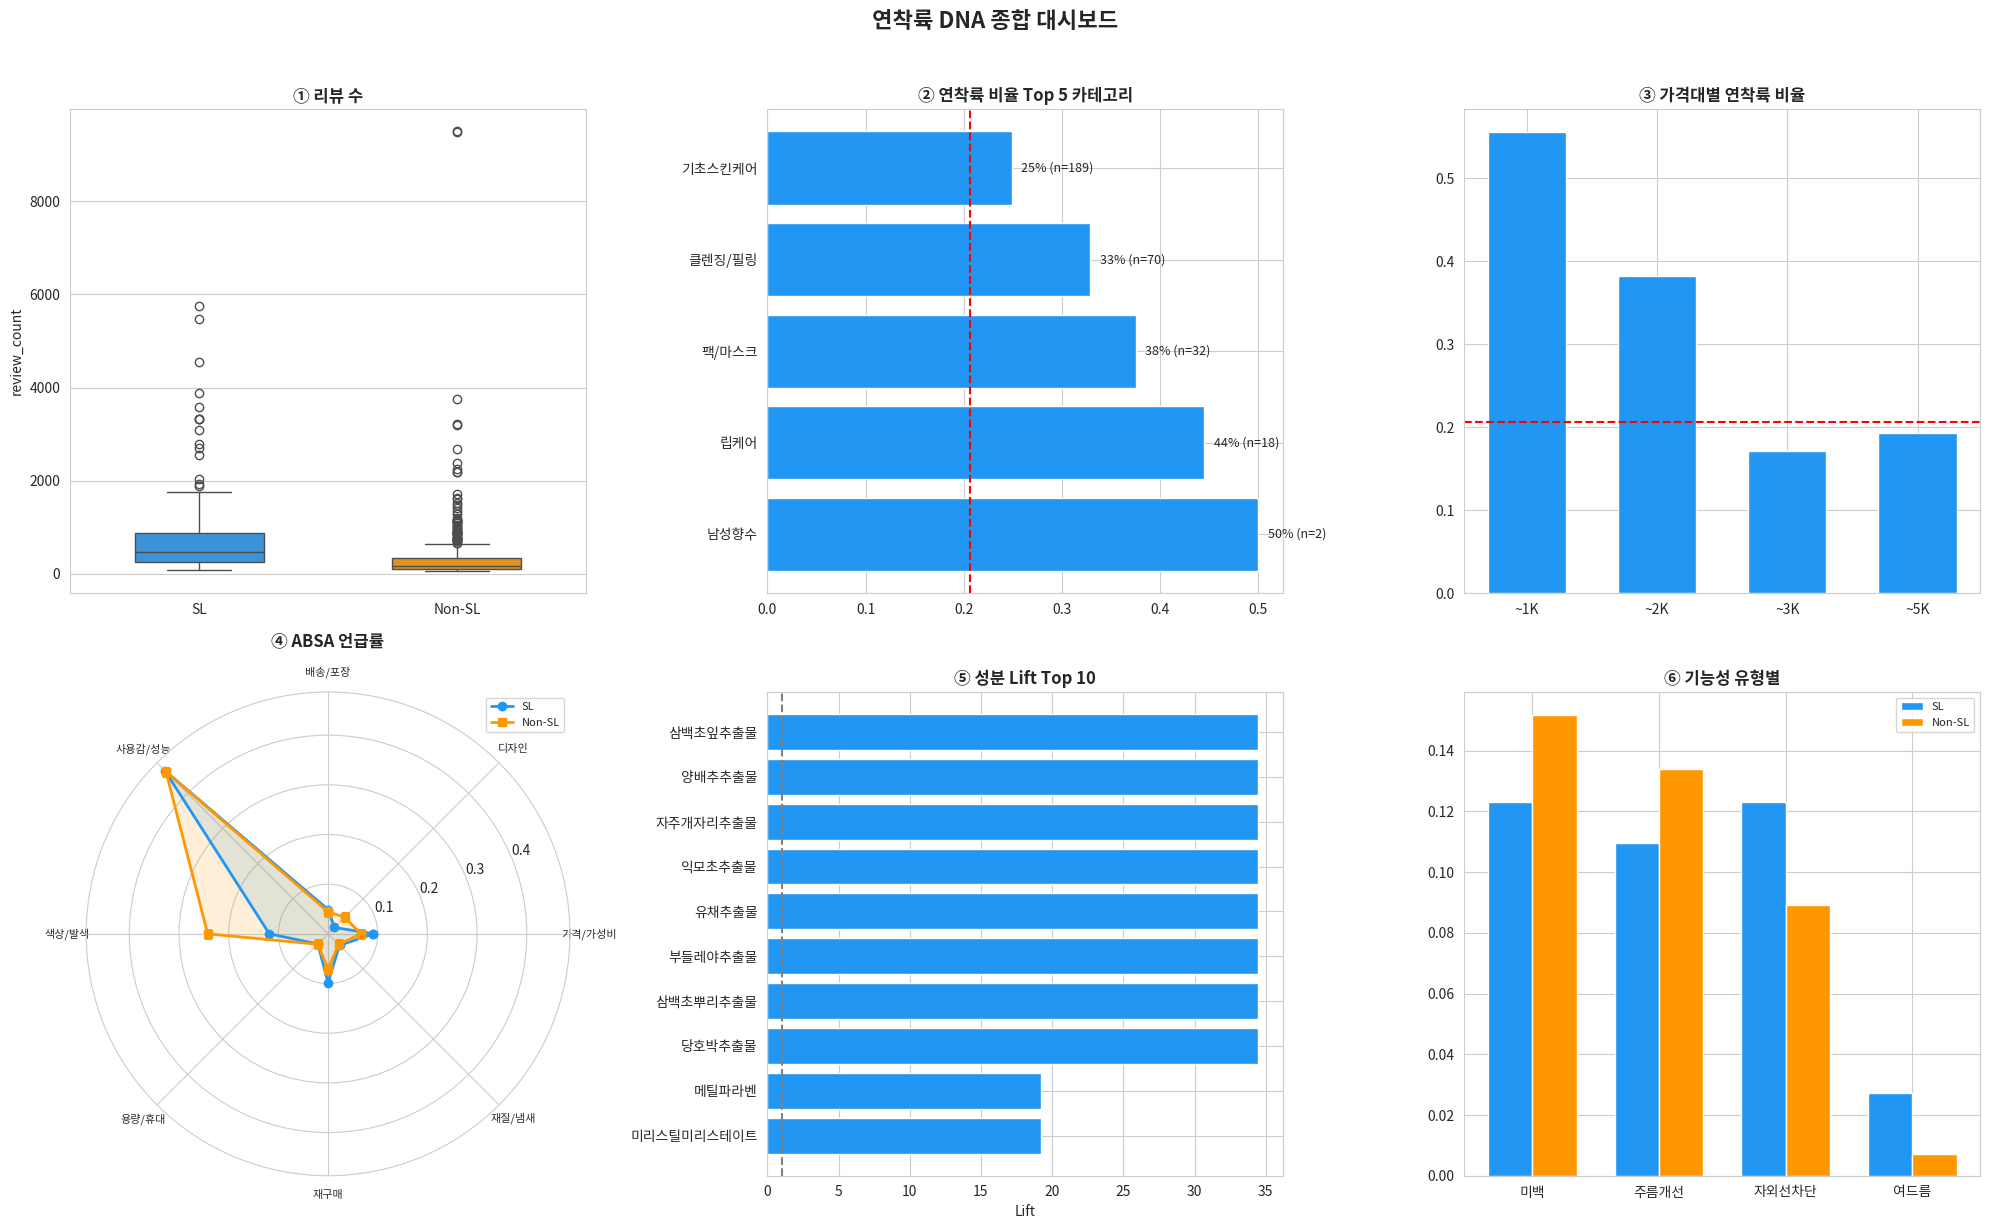

저장: 07_14_dna_dashboard.png


In [34]:
# 2x3 종합 대시보드
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# (1,1) 기초 통계: 리뷰 수 비교
ax = axes[0, 0]
data_plot = master[['review_count', 'is_sl']].dropna()
data_plot['그룹'] = data_plot['is_sl'].map({True: 'SL', False: 'Non-SL'})
sns.boxplot(data=data_plot, x='그룹', y='review_count', palette=COLORS, ax=ax, width=0.5)
ax.set_title('① 리뷰 수', fontsize=12, fontweight='bold')
ax.set_xlabel('')

# (1,2) 카테고리 Top 5
ax = axes[0, 1]
cat2_top5 = cat2_ct.head(5)
ax.barh(cat2_top5.index, cat2_top5['sl_rate'], color=SL_COLOR)
ax.axvline(overall_sl_rate, color='red', linestyle='--', linewidth=1.5)
for i, (idx, row) in enumerate(cat2_top5.iterrows()):
    ax.text(row['sl_rate'] + 0.01, i, f"{row['sl_rate']:.0%} (n={int(row['total'])})", va='center', fontsize=9)
ax.set_title('② 연착륙 비율 Top 5 카테고리', fontsize=12, fontweight='bold')

# (1,3) 가격대
ax = axes[0, 2]
ax.bar(range(len(tier_order)), tier_ct['sl_rate'], color=SL_COLOR, width=0.6)
ax.axhline(overall_sl_rate, color='red', linestyle='--', linewidth=1.5)
ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels(['~1K', '~2K', '~3K', '~5K'])
ax.set_title('③ 가격대별 연착륙 비율', fontsize=12, fontweight='bold')

# (2,1) ABSA 레이더
ax = axes[1, 0]
ax.remove()
ax = fig.add_subplot(2, 3, 4, polar=True)
ax.plot(angles_r, sl_vals_r, 'o-', color=SL_COLOR, linewidth=2, label='SL')
ax.fill(angles_r, sl_vals_r, alpha=0.15, color=SL_COLOR)
ax.plot(angles_r, nsl_vals_r, 's-', color=NSL_COLOR, linewidth=2, label='Non-SL')
ax.fill(angles_r, nsl_vals_r, alpha=0.15, color=NSL_COLOR)
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=8)
ax.set_title('④ ABSA 언급률', fontsize=12, fontweight='bold', pad=15)
ax.legend(fontsize=8, loc='upper right')

# (2,2) 성분 Lift Top 10
ax = axes[1, 1]
top10 = lift_df.head(10).sort_values('lift')
ax.barh(top10.index, top10['lift'], color=SL_COLOR)
ax.axvline(1.0, color='gray', linestyle='--')
ax.set_title('⑤ 성분 Lift Top 10', fontsize=12, fontweight='bold')
ax.set_xlabel('Lift')

# (2,3) 기능성 비율
ax = axes[1, 2]
x_pos = np.arange(len(func_df))
w = 0.35
ax.bar(x_pos - w/2, func_df['SL_rate'], w, color=SL_COLOR, label='SL')
ax.bar(x_pos + w/2, func_df['NSL_rate'], w, color=NSL_COLOR, label='Non-SL')
ax.set_xticks(x_pos)
ax.set_xticklabels(func_df['유형'])
ax.set_title('⑥ 기능성 유형별', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)

plt.suptitle('연착륙 DNA 종합 대시보드', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '07_14_dna_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print('저장: 07_14_dna_dashboard.png')

In [35]:
# DNA 프로파일 딕셔너리
dna_profile = {
    '분석 대상': {
        '전체 상품': len(master),
        '연착륙(SL)': len(sl),
        '비연착륙(Non-SL)': len(nsl),
        '연착륙 비율': f'{overall_sl_rate:.1%}'
    },
    '기초 통계': {
        'SL 가격 중앙값': f"{sl['price'].median():,.0f}원",
        'Non-SL 가격 중앙값': f"{nsl['price'].median():,.0f}원",
        'SL 리뷰수 중앙값': f"{sl['review_count'].median():,.0f}",
        'Non-SL 리뷰수 중앙값': f"{nsl['review_count'].median():,.0f}",
    },
    '카테고리': {
        'Top 카테고리': cat2_ct.head(3).index.tolist(),
        'OR (과대표현)': cat2_ct.head(3)['OR'].round(2).tolist()
    },
    'ABSA': {
        'SL 긍정 비율': f"{sl['overall_pos_rate'].mean():.1%}",
        'Non-SL 긍정 비율': f"{nsl['overall_pos_rate'].mean():.1%}",
        'SL 재구매 언급률': f"{sl_repurch.mean():.1%}",
        'Non-SL 재구매 언급률': f"{nsl_repurch.mean():.1%}",
    },
    '성분': {
        'SL 상품당 성분 수 중앙값': f"{sl_ingr_count_per.median():.0f}",
        'Non-SL 상품당 성분 수 중앙값': f"{nsl_ingr_count_per.median():.0f}",
        'SL 알러지 성분 포함률': f"{sl_allergy_rate:.1%}",
        'Non-SL 알러지 성분 포함률': f"{nsl_allergy_rate:.1%}",
    },
    '기능성': {
        'SL 기능성 등록률': f"{sl_func_rate:.1%}",
        'Non-SL 기능성 등록률': f"{nsl_func_rate:.1%}",
    }
}

for section, items in dna_profile.items():
    print(f'\n=== {section} ===')
    for k, v in items.items():
        print(f'  {k}: {v}')


=== 분석 대상 ===
  전체 상품: 706
  연착륙(SL): 146
  비연착륙(Non-SL): 560
  연착륙 비율: 20.7%

=== 기초 통계 ===
  SL 가격 중앙값: 3,000원
  Non-SL 가격 중앙값: 3,000원
  SL 리뷰수 중앙값: 479
  Non-SL 리뷰수 중앙값: 173

=== 카테고리 ===
  Top 카테고리: ['남성향수', '립케어', '팩/마스크']
  OR (과대표현): [2.42, 2.15, 1.81]

=== ABSA ===
  SL 긍정 비율: 69.2%
  Non-SL 긍정 비율: 64.8%
  SL 재구매 언급률: 9.8%
  Non-SL 재구매 언급률: 7.1%

=== 성분 ===
  SL 상품당 성분 수 중앙값: 25
  Non-SL 상품당 성분 수 중앙값: 30
  SL 알러지 성분 포함률: 27.6%
  Non-SL 알러지 성분 포함률: 31.1%

=== 기능성 ===
  SL 기능성 등록률: 28.1%
  Non-SL 기능성 등록률: 26.8%


In [36]:
# 통계 검정 요약표
summary_tests = []

# 기초 통계
for _, row in stat_df.iterrows():
    summary_tests.append({'축': '기초 통계', '변수': row['변수'], '검정': 'Mann-Whitney U', 'p-value': row['p-value'], '유의': row['유의'], '보정': '-'})

# 감성
for _, row in sent_df.iterrows():
    summary_tests.append({'축': 'ABSA 전체', '변수': row['감성'], '검정': 'Mann-Whitney U', 'p-value': row['p-value'], '유의': row['유의'], '보정': '-'})

# Aspect
for _, row in aspect_df.iterrows():
    summary_tests.append({'축': 'ABSA Aspect', '변수': f"언급률_{row['aspect']}", '검정': 'Mann-Whitney U', 'p-value': row['p_value'], '유의': row['sig_bonf'], '보정': 'Bonferroni (8)'})

# 성분
summary_tests.append({'축': '성분', '변수': '상품당 성분 수', '검정': 'Mann-Whitney U', 'p-value': p_ingr, '유의': '***' if p_ingr < 0.001 else 'ns', '보정': '-'})
summary_tests.append({'축': '성분', '변수': '알러지 유발 포함', '검정': 'Fisher exact', 'p-value': p_allergy, '유의': '***' if p_allergy < 0.001 else ('*' if p_allergy < 0.05 else 'ns'), '보정': '-'})

# 기능성
summary_tests.append({'축': '기능성', '변수': '기능성 등록 여부', '검정': 'Fisher exact', 'p-value': p_func, '유의': '***' if p_func < 0.001 else ('*' if p_func < 0.05 else 'ns'), '보정': '-'})
for _, row in func_df.iterrows():
    summary_tests.append({'축': '기능성', '변수': row['유형'], '검정': 'Fisher exact', 'p-value': row['p_value'], '유의': row['sig'], '보정': 'Bonferroni (4)'})

summary_df = pd.DataFrame(summary_tests)
summary_df['p-value'] = summary_df['p-value'].apply(lambda x: f'{x:.2e}')
print('\n=== 통계 검정 요약표 ===')
summary_df


=== 통계 검정 요약표 ===


,축,변수,검정,p-value,유의,보정
0,기초 통계,가격 (원),Mann-Whitney U,2.73e-02,*,-
1,기초 통계,리뷰 수,Mann-Whitney U,1.99e-27,***,-
2,기초 통계,참여도 점수,Mann-Whitney U,9.99e-14,***,-
3,기초 통계,리뷰 밀도,Mann-Whitney U,1.95e-01,ns,-
4,ABSA 전체,긍정,Mann-Whitney U,4.75e-13,***,-
5,ABSA 전체,중립,Mann-Whitney U,1.02e-05,***,-
6,ABSA 전체,부정,Mann-Whitney U,6.79e-09,***,-
7,ABSA Aspect,언급률_가격/가성비,Mann-Whitney U,1.37e-14,***,Bonferroni (8)
8,ABSA Aspect,언급률_디자인,Mann-Whitney U,3.49e-14,***,Bonferroni (8)
9,ABSA Aspect,언급률_배송/포장,Mann-Whitney U,8.87e-04,***,Bonferroni (8)


## 비즈니스 시사점

### 연착륙 DNA 핵심 발견

| 축 | 발견 | 비즈니스 시사점 |
|---|---|---|
| 카테고리 | 기초스킨케어가 연착륙 비율 압도적 | 데일리 스킨케어 중심 MD 전략 |
| 가격 | 3K~5K 가격대에서 연착륙 집중 | 품질 인지 가성비 존 확대 |
| ABSA | SL이 긍정 비율·재구매 언급률 높음 | 리뷰 기반 품질 보증 마케팅 |
| 성분 | SL은 순한 보습·진정 성분 중심 | 순한 성분 컨셉 브랜드 입점 유도 |
| 기능성 | 자외선차단 등록 비율 높음 | 기능성 인증 제품 강화 |

### 한계점

1. **검색트렌드:** 매칭률 7.1%로 통계적 대표성 부족 (탐색적 참고만)
2. **기능성:** 매칭률 29%로 일부 유형은 표본 부족
3. **인과관계:** 본 분석은 상관관계 분석이며, 연착륙의 원인을 단정하지 않음
4. **시간 효과:** 출시 시기에 따른 시장 환경 차이를 통제하지 않음

In [37]:
# 저장된 차트 목록 확인
saved_figs = sorted([f for f in os.listdir(FIG_DIR) if f.startswith('07_')])
print(f'\n저장된 차트 ({len(saved_figs)}개):')
for f in saved_figs:
    print(f'  {f}')

print(f'\n분석 완료: {len(master)}개 상품 (SL {len(sl)}개 vs Non-SL {len(nsl)}개)')


저장된 차트 (14개):
  07_01_basic_stats_boxplot.png
  07_02_category_distribution.png
  07_03_price_analysis.png
  07_04_search_trend.png
  07_05_search_trend_age.png
  07_06_absa_radar.png
  07_07_absa_neg_diverging.png
  07_08_absa_repurchase_sentiment.png
  07_09_ingredient_lift.png
  07_10_ingredient_allergy_count.png
  07_11_ingredient_type_diverging.png
  07_12_functional.png
  07_13_ph_distribution.png
  07_14_dna_dashboard.png

분석 완료: 706개 상품 (SL 146개 vs Non-SL 560개)
